# OULAD — Exploratory Data Analysis

**Data discription:**
- **Hồ sơ nhập học (studentInfo):** Sinh viên này là ai? Nam hay nữ? Trình độ học vấn ra sao? Sống ở vùng nghèo hay giàu (imd_band)? Bảng này chứa kết quả cuối cùng (final_result) - đây chính là thứ homie cần dự đoán.
- **Đăng ký môn (courses & studentRegistration):** Sinh viên đăng ký học môn gì (Module)? Học kỳ nào (Presentation: B là tháng 2, J là tháng 10)? Có hủy môn giữa chừng không (date_unregistration)?
- **Hành vi học tập (vle & studentVle):** Đây là mỏ vàng. Nó ghi lại từng cú click chuột của sinh viên trên hệ thống học trực tuyến (VLE). Sinh viên click vào bài giảng nào, ngày thứ mấy của khóa học, click bao nhiêu lần.
- **Kiểm tra & Điểm số (assessments & studentAssessment):** Khóa học có mấy bài Test? Hạn chót nộp là ngày nào? Sinh viên nộp bài ngày thứ mấy và được bao nhiêu điểm?

**Mục tiêu:** EDA toàn diện trước khi split, chỉ để *khám phá và hiểu data*. Không có con số nào ở đây được dùng để transform data (mean, std, threshold phải tính lại từ train set sau khi split).

| Section | Nội dung |
|---|---|
| 0 | Setup & Data Loading |
| 1 | Schema Overview |
| 2 | Semantic Null Analysis |
| 3 | Target Variable Analysis |
| 4 | Module Structure Audit |
| 5 | Presentation Effect (B vs J) |
| 6 | Cut-off Selection (Data-driven) |
| 7 | Leakage Audit |
| 8 | VLE Time-series Analysis |

---
## Section 0 — Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42

# ── CONFIG ──────────────────────────────────────────────────────────────────
# Nếu notebook không tìm được data tự động, set tay vào đây:
MANUAL_DATA_DIR = None   # VD: r'C:\Users\ten\data'  hoặc '/home/user/data'
# ────────────────────────────────────────────────────────────────────────────

def _find_data_dir():
    if MANUAL_DATA_DIR:
        return Path(MANUAL_DATA_DIR)
    candidates = [
        Path(os.getcwd()),
        Path(os.getcwd()) / 'data',
        Path(os.getcwd()).parent / 'data',
        Path(os.getcwd()).parent,
    ]
    for p in candidates:
        if (p / 'studentInfo.csv').exists():
            return p
    raise FileNotFoundError(
        'Không tìm thấy studentInfo.csv.\n'
        'Set MANUAL_DATA_DIR = "<path>" ở trên.'
    )

DATA_DIR = _find_data_dir()

REQUIRED = ['studentInfo.csv','studentRegistration.csv','studentAssessment.csv',
            'studentVle.csv','assessments.csv','courses.csv','vle.csv']
missing_files = [f for f in REQUIRED if not (DATA_DIR / f).exists()]

print(f'DATA_DIR = {DATA_DIR.resolve()}')
if missing_files:
    print('⚠ Thiếu file:', missing_files)
else:
    print('✓ Tất cả 7 file CSV đều có mặt.')

DATA_DIR = D:\CS-313-Data-Mining\data
✓ Tất cả 7 file CSV đều có mặt.


---
## Section 1 — Schema Overview
Nhìn nhanh toàn bộ dataset: shape, kiểu dữ liệu, missing.

=== SCHEMA OVERVIEW ===
                               Rows  Cols  Cols w/ Nulls                            Null Columns
File                                                                                            
studentInfo.csv              32,593    12              1                                imd_band
studentRegistration.csv      32,593     5              2  date_registration, date_unregistration
studentAssessment.csv       173,912     5              1                                   score
studentVle.csv           10,655,280     6              0                                       —
assessments.csv                 206     6              1                                    date
courses.csv                      22     3              0                                       —
vle.csv                       6,364     6              2                      week_from, week_to


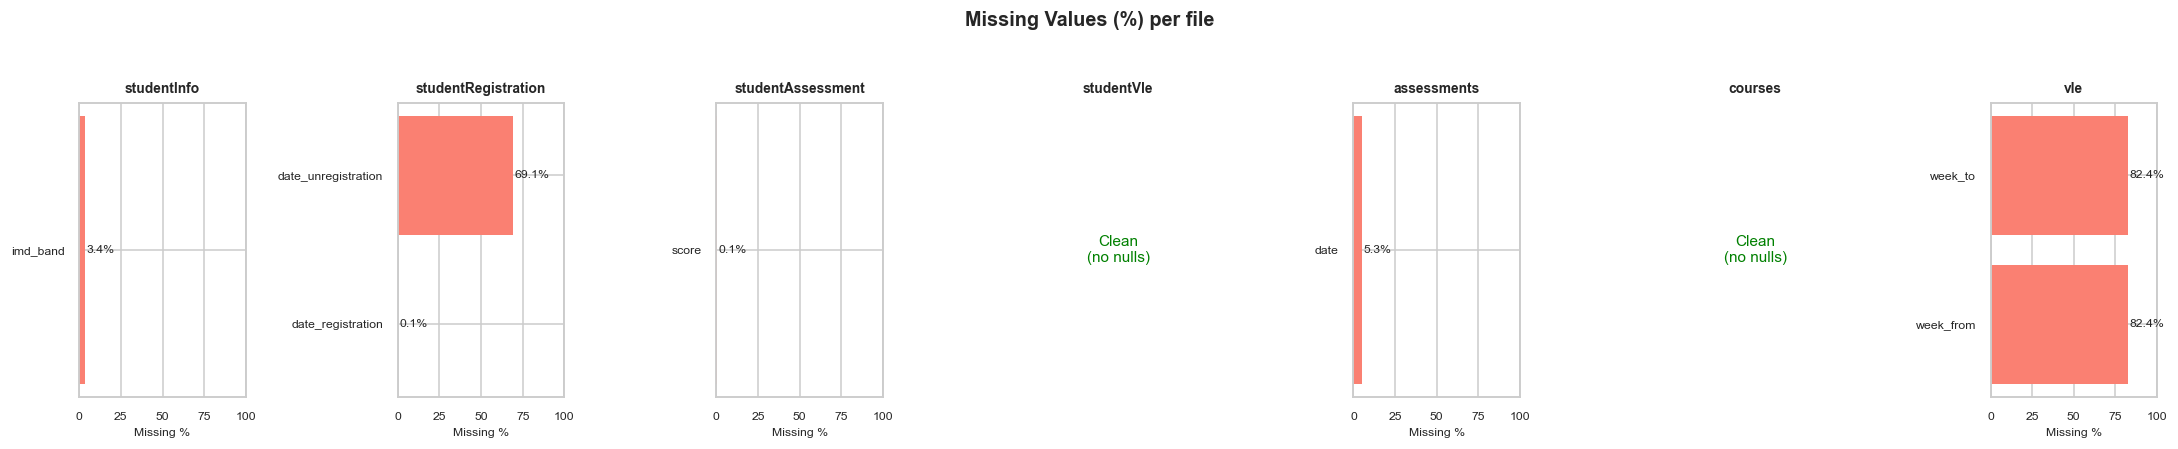

In [2]:
def section1_schema_overview():
    rows = []
    for f in REQUIRED:
        df = pd.read_csv(DATA_DIR / f)
        n_rows, n_cols = df.shape
        null_cols = df.columns[df.isnull().any()].tolist()
        rows.append({
            'File': f,
            'Rows': f'{n_rows:,}',
            'Cols': n_cols,
            'Cols w/ Nulls': len(null_cols),
            'Null Columns': ', '.join(null_cols) if null_cols else '—',
        })

    summary = pd.DataFrame(rows).set_index('File')
    print('=== SCHEMA OVERVIEW ===')
    print(summary.to_string())

    # ── Visualize: heatmap missing per file ──────────────────────────────
    fig, axes = plt.subplots(1, len(REQUIRED), figsize=(20, 4))
    for ax, f in zip(axes, REQUIRED):
        df = pd.read_csv(DATA_DIR / f)
        miss = (df.isnull().mean() * 100).reset_index()
        miss.columns = ['Column', 'Missing %']
        miss = miss[miss['Missing %'] > 0]
        if miss.empty:
            ax.text(0.5, 0.5, 'Clean\n(no nulls)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='green')
            ax.set_title(f.replace('.csv',''), fontsize=9, fontweight='bold')
            ax.axis('off')
        else:
            bars = ax.barh(miss['Column'], miss['Missing %'], color='salmon', edgecolor='none')
            ax.set_xlim(0, 100)
            ax.set_xlabel('Missing %', fontsize=8)
            ax.set_title(f.replace('.csv',''), fontsize=9, fontweight='bold')
            ax.tick_params(labelsize=8)
            for bar, val in zip(bars, miss['Missing %']):
                ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                        f'{val:.1f}%', va='center', fontsize=8)

    plt.suptitle('Missing Values (%) per file', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

section1_schema_overview()

---
## Section 2 — Semantic Null Analysis

Null không phải lúc nào cũng là "thiếu dữ liệu". Cần kiểm tra ý nghĩa logic trước khi quyết định xử lý.

- **`date_unregistration`**: NaN = *"không rút môn, học đến cuối"*, không phải missing
- **`score`**: NaN = *"không nộp bài"*, nên coi là điểm 0, không phải lỗi hệ thống

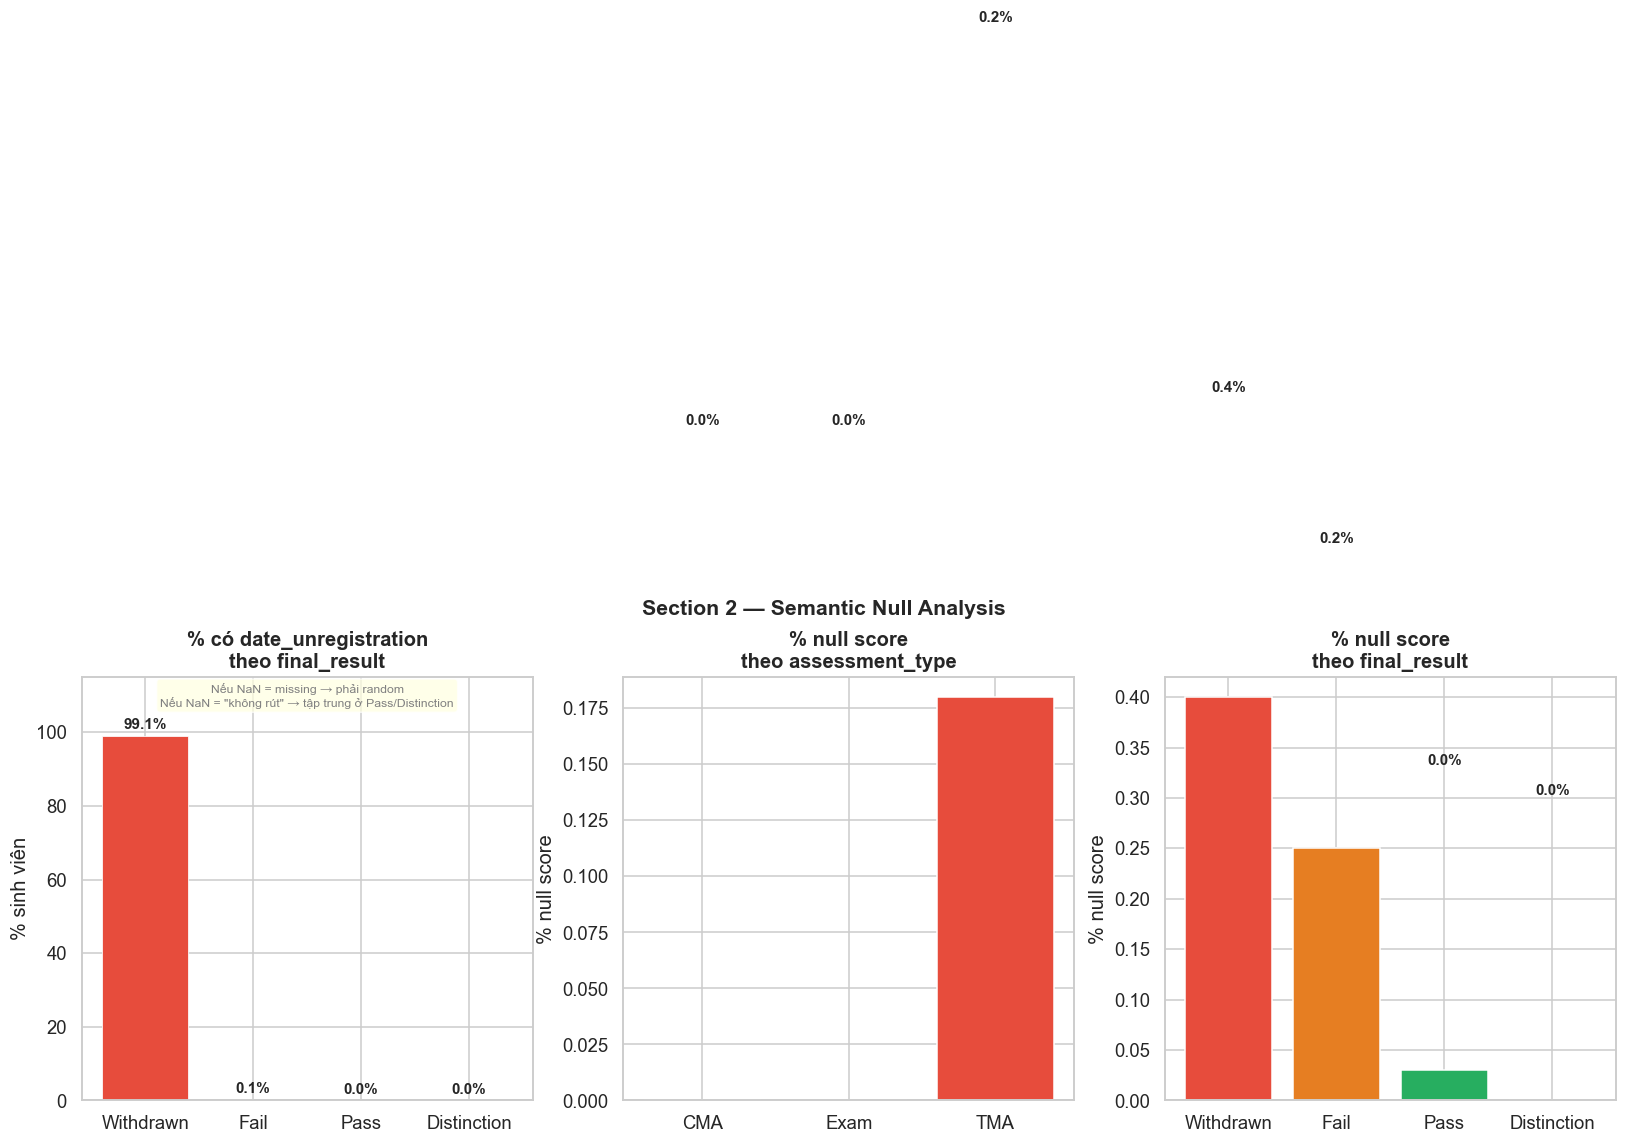


✓ Kết luận:
  date_unregistration = NaN → "học đến cuối", KHÔNG dropna()
  score = NaN → "không nộp bài" = 0, dùng fillna(0)


In [3]:
def section2_semantic_null():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')

    merged_reg = df_reg.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    merged_reg['has_unreg'] = merged_reg['date_unregistration'].notna()

    # ── Null score by assessment_type ────────────────────────────────────
    merged_sa = df_sa.merge(df_ass[['id_assessment','assessment_type']], on='id_assessment')
    null_by_type = (
        merged_sa.groupby('assessment_type')['score']
        .apply(lambda x: x.isna().mean() * 100)
        .round(2)
        .reset_index()
        .rename(columns={'score': 'null_pct'})
    )

    # ── Null score by final_result ────────────────────────────────────────
    merged_sa2 = df_sa.merge(
        df_info[['id_student','final_result']], on='id_student'
    )
    null_by_result = (
        merged_sa2.groupby('final_result')['score']
        .apply(lambda x: x.isna().mean() * 100)
        .round(2)
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={'score': 'null_pct'})
    )

    # ── Plot ─────────────────────────────────────────────────────────────
    result_order = ['Withdrawn','Fail','Pass','Distinction']
    result_colors = {'Withdrawn':'#e74c3c','Fail':'#e67e22','Pass':'#27ae60','Distinction':'#2980b9'}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: % has date_unregistration by final_result
    unreg_tbl = (
        merged_reg.groupby('final_result')['has_unreg']
        .mean().mul(100).round(2)
        .reindex(result_order).reset_index()
    )
    bar_colors = [result_colors[r] for r in unreg_tbl['final_result']]
    bars = axes[0].bar(unreg_tbl['final_result'], unreg_tbl['has_unreg'],
                       color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, unreg_tbl['has_unreg']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[0].set_title('% có date_unregistration\ntheo final_result', fontweight='bold')
    axes[0].set_ylabel('% sinh viên')
    axes[0].set_ylim(0, 115)
    axes[0].set_xlabel('')
    axes[0].text(0.5, 0.93,
                 'Nếu NaN = missing → phải random\nNếu NaN = "không rút" → tập trung ở Pass/Distinction',
                 ha='center', transform=axes[0].transAxes, fontsize=8, color='gray',
                 bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.7))

    # Chart 2: null score % by assessment_type
    colors2 = ['#3498db','#e67e22','#e74c3c']
    bars2 = axes[1].bar(null_by_type['assessment_type'], null_by_type['null_pct'],
                        color=colors2[:len(null_by_type)], edgecolor='white')
    for bar, val in zip(bars2, null_by_type['null_pct']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].set_title('% null score\ntheo assessment_type', fontweight='bold')
    axes[1].set_ylabel('% null score')
    axes[1].set_xlabel('')

    # Chart 3: null score % by final_result
    ordered = null_by_result.set_index('final_result').reindex(result_order).reset_index()
    bar_colors3 = [result_colors[r] for r in ordered['final_result']]
    bars3 = axes[2].bar(ordered['final_result'], ordered['null_pct'],
                        color=bar_colors3, edgecolor='white')
    for bar, val in zip(bars3, ordered['null_pct']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[2].set_title('% null score\ntheo final_result', fontweight='bold')
    axes[2].set_ylabel('% null score')
    axes[2].set_xlabel('')

    plt.suptitle('Section 2 — Semantic Null Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print('\n✓ Kết luận:')
    print('  date_unregistration = NaN → "học đến cuối", KHÔNG dropna()')
    print('  score = NaN → "không nộp bài" = 0, dùng fillna(0)')

section2_semantic_null()

---
## Section 3 — Target Variable Analysis

Phân tích `final_result` (4 nhãn gốc) và profile nhân khẩu học theo từng nhóm.

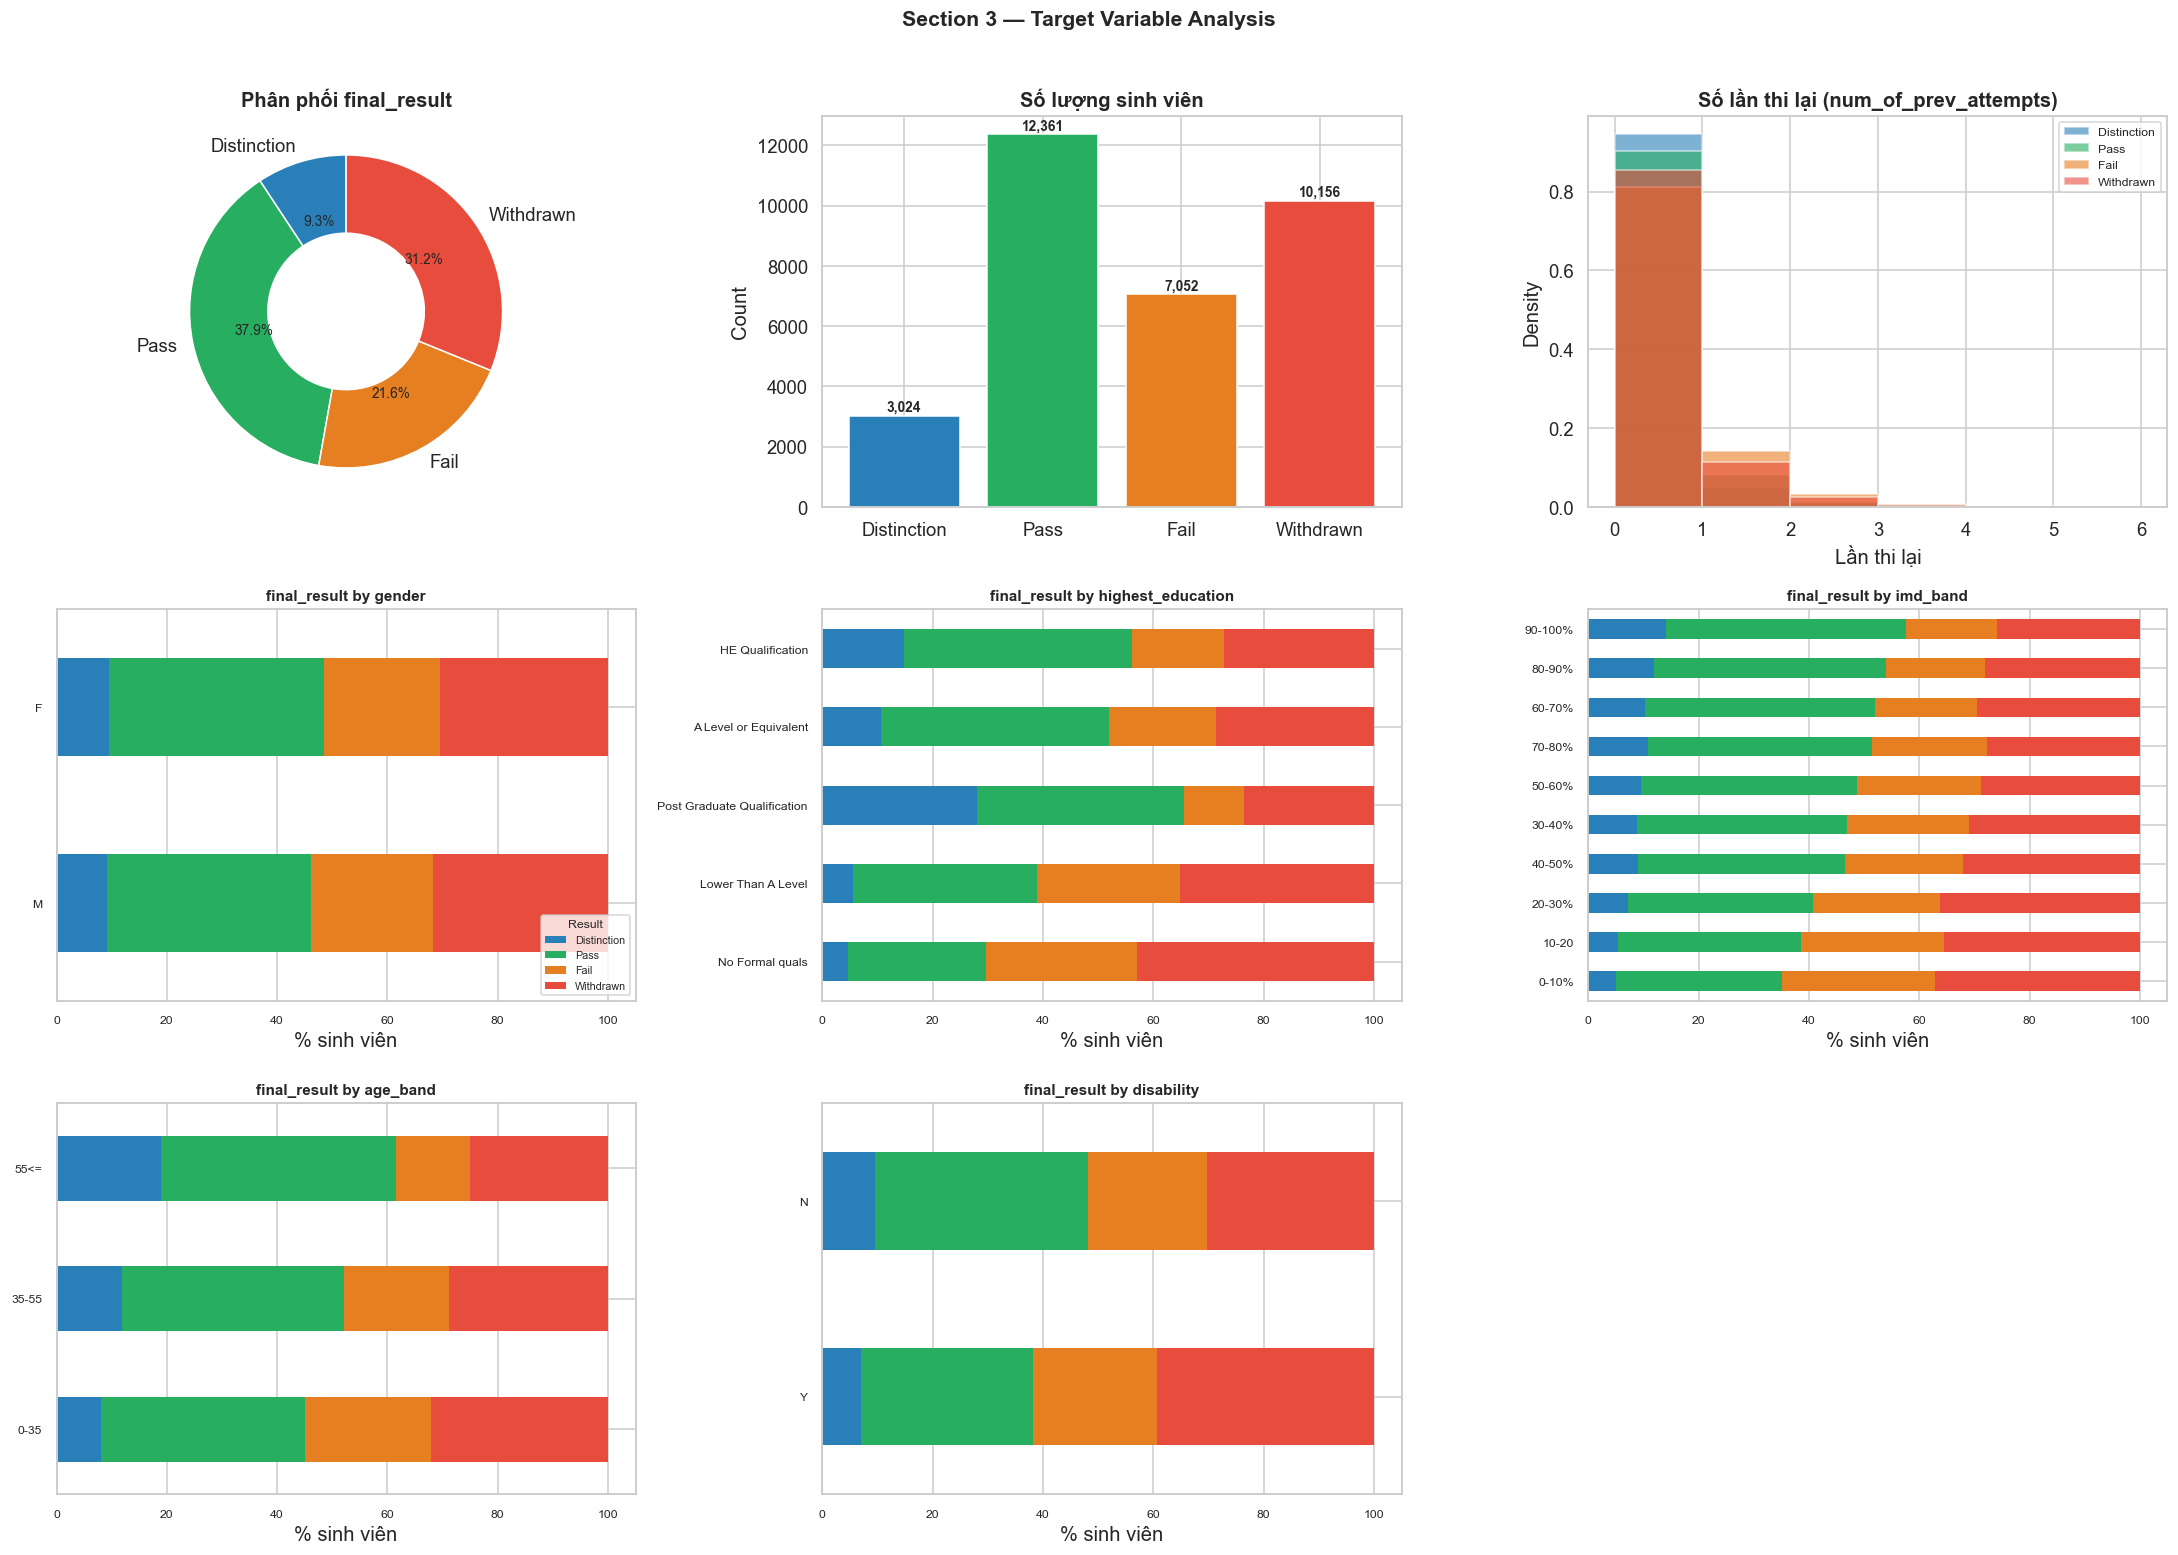

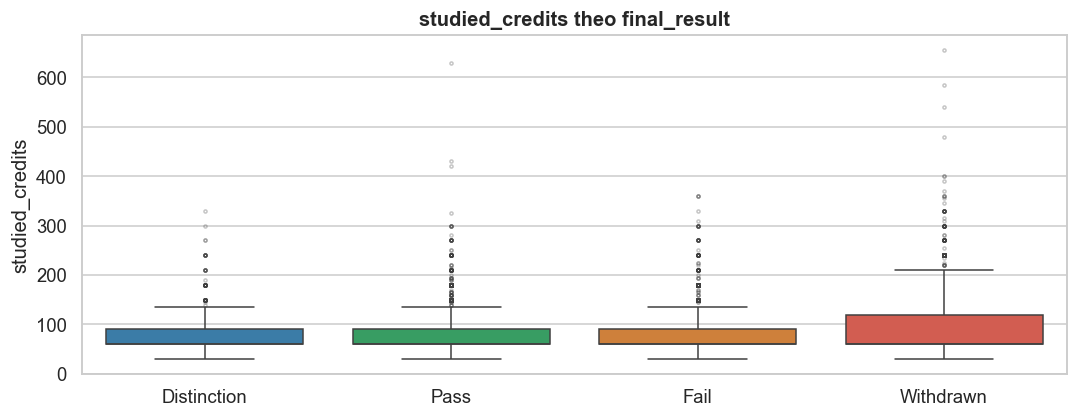

In [4]:
def section3_target_analysis():
    df = pd.read_csv(DATA_DIR / 'studentInfo.csv')

    result_order  = ['Distinction','Pass','Fail','Withdrawn']
    result_colors = ['#2980b9','#27ae60','#e67e22','#e74c3c']
    result_palette = dict(zip(result_order, result_colors))

    # ── Fig 1: Distribution + profile ────────────────────────────────────
    demo_cols = ['gender','highest_education','imd_band','age_band','disability']
    n_demo = len(demo_cols)

    fig = plt.figure(figsize=(20, 14))

    # Row 0: Overall distribution (donut + bar)
    ax_donut = fig.add_subplot(3, 3, 1)
    counts = df['final_result'].value_counts().reindex(result_order)
    wedges, texts, autotexts = ax_donut.pie(
        counts, labels=counts.index, colors=result_colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white')
    )
    for at in autotexts:
        at.set_fontsize(9)
    ax_donut.set_title('Phân phối final_result', fontweight='bold')

    # Bar count
    ax_bar = fig.add_subplot(3, 3, 2)
    bars = ax_bar.bar(result_order, counts.values, color=result_colors, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax_bar.set_title('Số lượng sinh viên', fontweight='bold')
    ax_bar.set_ylabel('Count')

    # num_of_prev_attempts by result
    ax_prev = fig.add_subplot(3, 3, 3)
    for res, color in zip(result_order, result_colors):
        subset = df[df['final_result'] == res]['num_of_prev_attempts']
        ax_prev.hist(subset, bins=range(0, 7), alpha=0.6, label=res, color=color, density=True)
    ax_prev.set_title('Số lần thi lại (num_of_prev_attempts)', fontweight='bold')
    ax_prev.set_xlabel('Lần thi lại')
    ax_prev.set_ylabel('Density')
    ax_prev.legend(fontsize=8)

    # Demo cols: stacked % bar
    for idx, col in enumerate(demo_cols):
        ax = fig.add_subplot(3, 3, idx + 4)
        if col not in df.columns:
            ax.axis('off')
            continue
        ct = pd.crosstab(df[col], df['final_result'], normalize='index')[result_order] * 100
        ct = ct.sort_values('Pass', ascending=True)
        ct.plot(kind='barh', stacked=True, ax=ax,
                color=result_colors, edgecolor='none', legend=(idx == 0))
        ax.set_title(f'final_result by {col}', fontweight='bold', fontsize=10)
        ax.set_xlabel('% sinh viên')
        ax.set_ylabel('')
        ax.tick_params(labelsize=8)
        if idx == 0:
            ax.legend(title='Result', fontsize=7, title_fontsize=8,
                      loc='lower right', bbox_to_anchor=(1.0, 0))

    plt.suptitle('Section 3 — Target Variable Analysis', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Studied credits by result ─────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    df_plot = df[df['final_result'].isin(result_order)].copy()
    df_plot['final_result'] = pd.Categorical(df_plot['final_result'], categories=result_order)
    sns.boxplot(data=df_plot, x='final_result', y='studied_credits',
                palette=result_palette, order=result_order, ax=ax2,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax2.set_title('studied_credits theo final_result', fontweight='bold')
    ax2.set_xlabel('')
    plt.tight_layout()
    plt.show()

section3_target_analysis()

---
## Section 4 — Module Structure Audit

Mỗi module có cấu trúc đánh giá khác nhau. **Không thể so sánh raw score cross-module.**

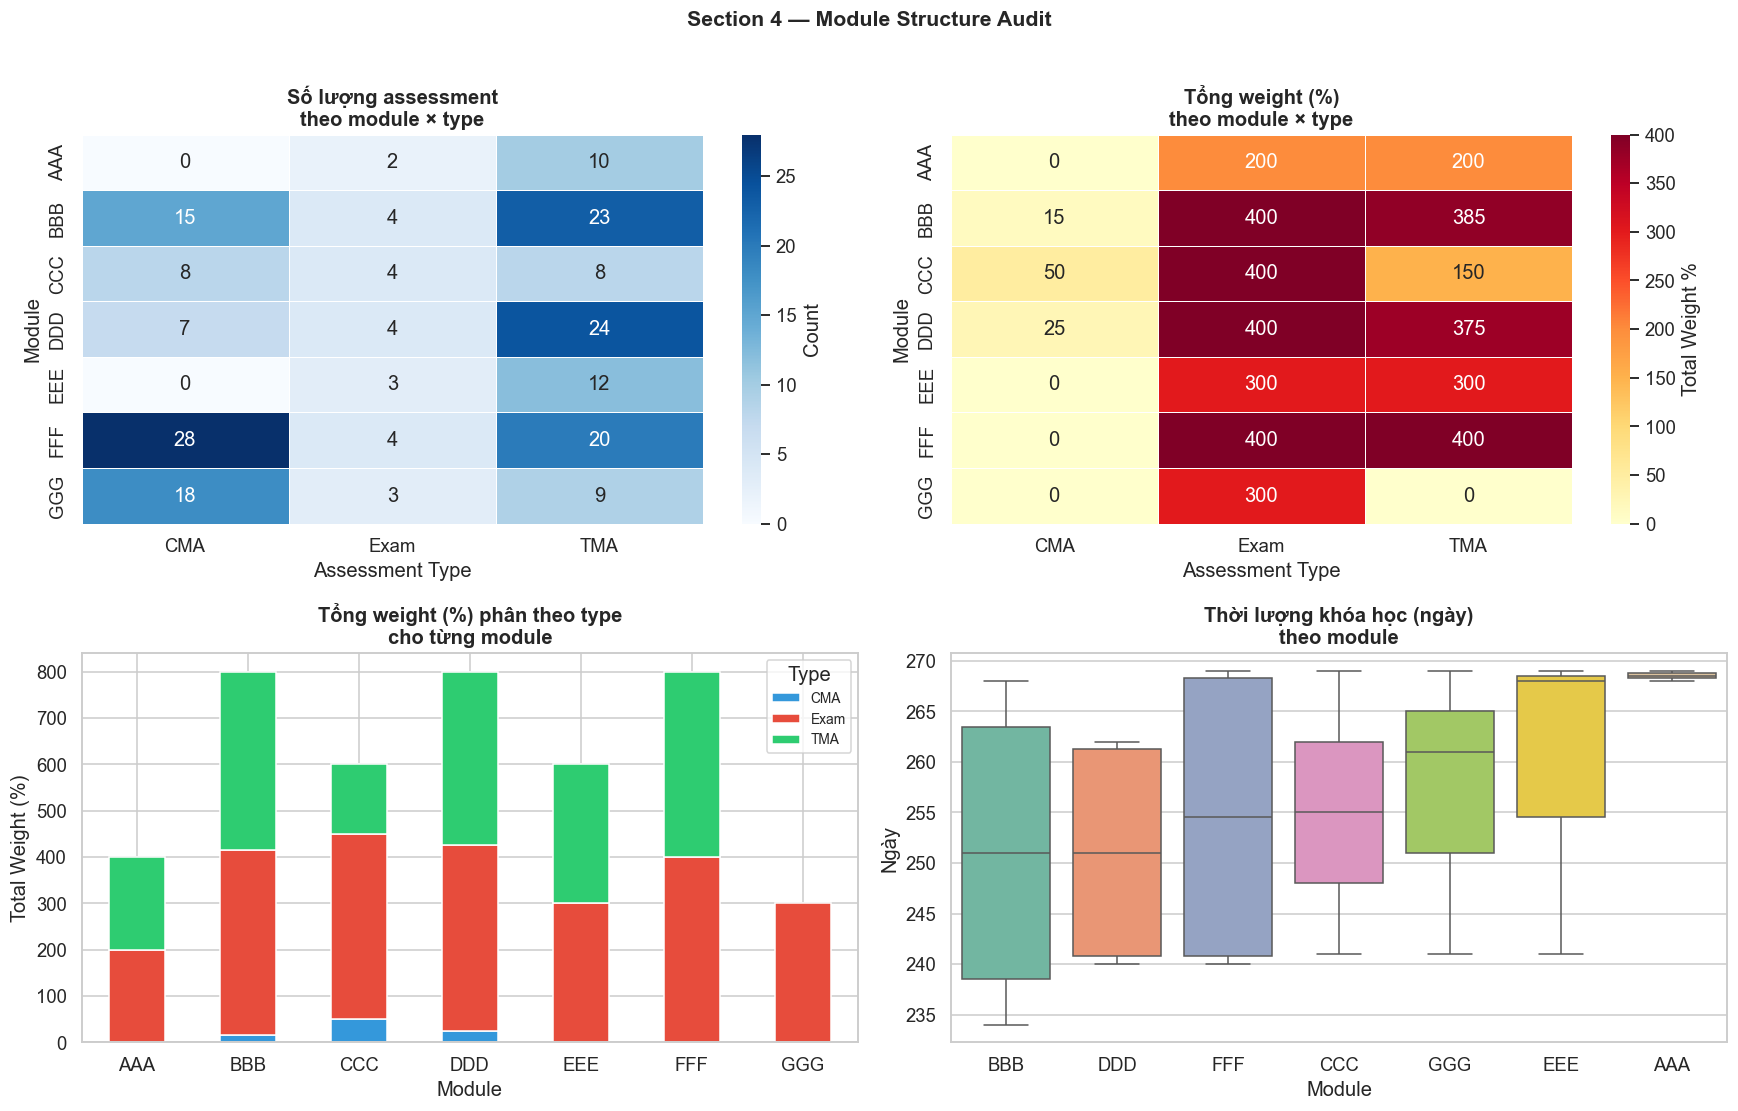


✓ Kết luận: Các module có cấu trúc đánh giá khác nhau.
  → Không gộp raw score cross-module. Phải normalize per-module hoặc dùng weighted score.


In [5]:
def section4_module_structure():
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_crs  = pd.read_csv(DATA_DIR / 'courses.csv')

    # Thời lượng per module
    dur = df_crs.groupby('code_module')['module_presentation_length'].agg(['min','mean','max']).round(1)

    # Assessment count + weight per module x type
    pivot_count  = df_ass.groupby(['code_module','assessment_type'])['id_assessment'].count().unstack(fill_value=0)
    pivot_weight = df_ass.groupby(['code_module','assessment_type'])['weight'].sum().unstack(fill_value=0)

    modules = sorted(df_ass['code_module'].unique())
    ass_types = sorted(df_ass['assessment_type'].unique())
    type_colors = {'CMA':'#3498db', 'Exam':'#e74c3c', 'TMA':'#2ecc71'}

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Chart 1: assessment count heatmap
    sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes[0][0], cbar_kws={'label': 'Count'})
    axes[0][0].set_title('Số lượng assessment\ntheo module × type', fontweight='bold')
    axes[0][0].set_xlabel('Assessment Type')
    axes[0][0].set_ylabel('Module')

    # Chart 2: total weight heatmap
    sns.heatmap(pivot_weight, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[0][1], cbar_kws={'label': 'Total Weight %'})
    axes[0][1].set_title('Tổng weight (%)\ntheo module × type', fontweight='bold')
    axes[0][1].set_xlabel('Assessment Type')
    axes[0][1].set_ylabel('Module')

    # Chart 3: stacked weight bar per module
    pivot_weight.plot(kind='bar', stacked=True, ax=axes[1][0],
                      color=[type_colors.get(t,'gray') for t in pivot_weight.columns],
                      edgecolor='white')
    axes[1][0].set_title('Tổng weight (%) phân theo type\ncho từng module', fontweight='bold')
    axes[1][0].set_xlabel('Module')
    axes[1][0].set_ylabel('Total Weight (%)')
    axes[1][0].tick_params(axis='x', rotation=0)
    axes[1][0].legend(title='Type', fontsize=9)

    # Chart 4: module duration boxplot
    module_dur = df_crs.copy()
    order_dur = module_dur.groupby('code_module')['module_presentation_length'].median().sort_values().index
    sns.boxplot(data=module_dur, x='code_module', y='module_presentation_length',
                order=order_dur, palette='Set2', ax=axes[1][1])
    axes[1][1].set_title('Thời lượng khóa học (ngày)\ntheo module', fontweight='bold')
    axes[1][1].set_xlabel('Module')
    axes[1][1].set_ylabel('Ngày')

    plt.suptitle('Section 4 — Module Structure Audit', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print('\n✓ Kết luận: Các module có cấu trúc đánh giá khác nhau.')
    print('  → Không gộp raw score cross-module. Phải normalize per-module hoặc dùng weighted score.')

section4_module_structure()

---
## Section 5 — Presentation Effect (B vs J)

Kỳ `B` (tháng 2) và kỳ `J` (tháng 10) có lịch học khác nhau. Nếu pass rate chênh nhiều → cần thêm feature `semester`.

Pass rate theo semester (%):
          pass_rate  n_students
semester                       
B             43.67       12488
J             49.40       20105

Pass rate per module x semester (%):
semester         B      J  diff
code_module                    
AAA            NaN  70.99   NaN
BBB          45.27  49.11 -3.84
CCC          34.25  40.63 -6.38
DDD          39.08  43.33 -4.25
EEE          51.44  57.72 -6.28
FFF          46.11  47.59 -1.48
GGG          57.38  60.91 -3.53


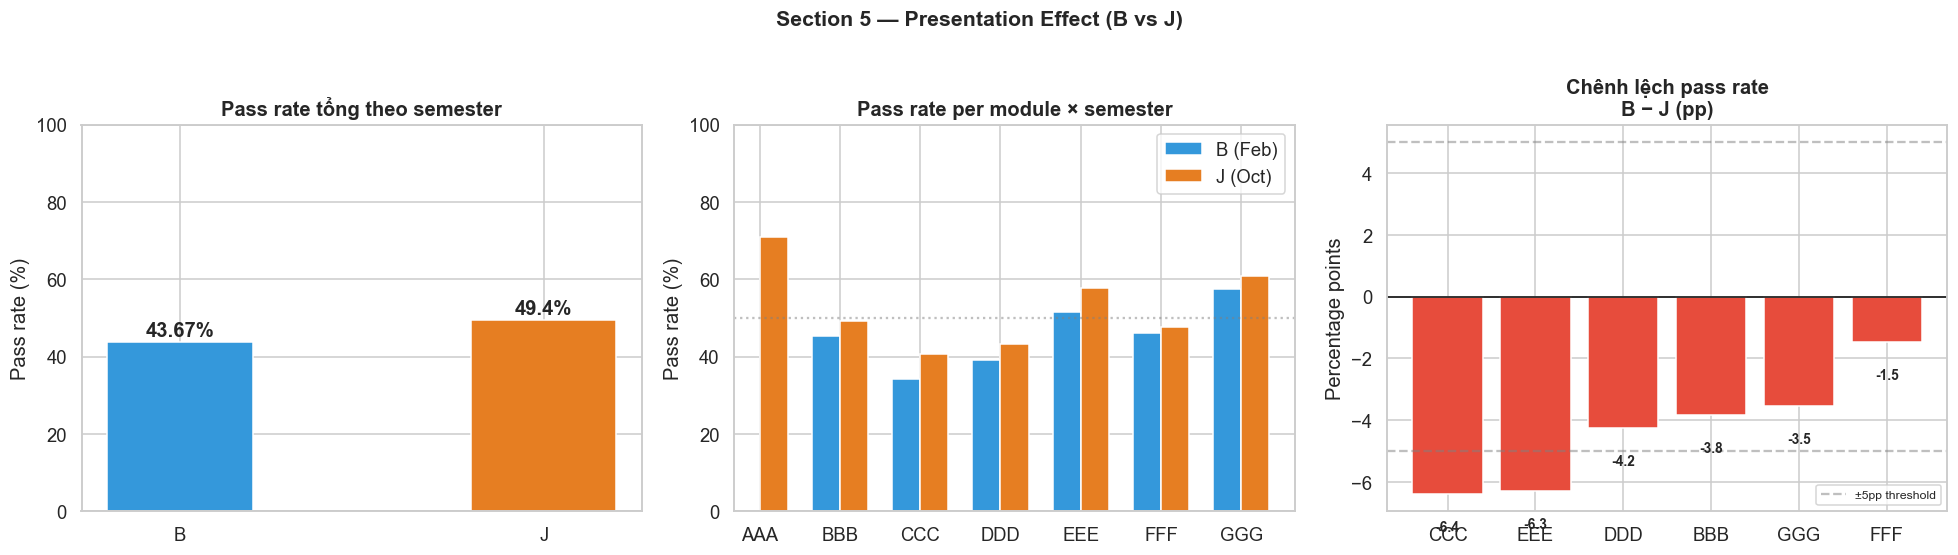


✓ Nếu |diff| > 5pp ở nhiều module → cần thêm feature semester hoặc train separate.


In [6]:
def section5_presentation_effect():
    df = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df['semester'] = df['code_presentation'].str[-1]
    df['is_pass']  = df['final_result'].isin(['Pass','Distinction']).astype(int)

    # Pass rate: tổng và per module
    overall = df.groupby('semester')['is_pass'].agg(['mean','count']).rename(
        columns={'mean':'pass_rate','count':'n_students'})
    overall['pass_rate'] = overall['pass_rate'].mul(100).round(2)

    per_module = (
        df.groupby(['code_module','semester'])['is_pass']
        .mean().mul(100).round(2).unstack()
    )
    if 'B' in per_module.columns and 'J' in per_module.columns:
        per_module['diff'] = (per_module['B'] - per_module['J']).round(2)

    print('Pass rate theo semester (%):')
    print(overall)
    print('\nPass rate per module x semester (%):')
    print(per_module)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: overall pass rate
    colors_sem = {'B':'#3498db','J':'#e67e22'}
    bars = axes[0].bar(overall.index, overall['pass_rate'],
                       color=[colors_sem.get(s,'gray') for s in overall.index],
                       edgecolor='white', width=0.4)
    for bar, val in zip(bars, overall['pass_rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val}%', ha='center', va='bottom', fontweight='bold')
    axes[0].set_title('Pass rate tổng theo semester', fontweight='bold')
    axes[0].set_ylabel('Pass rate (%)')
    axes[0].set_ylim(0, 100)

    # Chart 2: per module x semester grouped bar
    if 'B' in per_module.columns and 'J' in per_module.columns:
        x = np.arange(len(per_module))
        w = 0.35
        axes[1].bar(x - w/2, per_module['B'], w, label='B (Feb)', color='#3498db', edgecolor='white')
        axes[1].bar(x + w/2, per_module['J'], w, label='J (Oct)', color='#e67e22', edgecolor='white')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(per_module.index)
        axes[1].set_title('Pass rate per module × semester', fontweight='bold')
        axes[1].set_ylabel('Pass rate (%)')
        axes[1].set_ylim(0, 100)
        axes[1].legend()
        axes[1].axhline(50, color='gray', linestyle=':', alpha=0.5)

        # Chart 3: diff B - J
        diff_sorted = per_module['diff'].sort_values()
        bar_colors = ['#e74c3c' if v < 0 else '#27ae60' for v in diff_sorted]
        bars3 = axes[2].bar(diff_sorted.index, diff_sorted.values,
                             color=bar_colors, edgecolor='white')
        axes[2].axhline(0, color='black', linewidth=1)
        axes[2].axhline(5,  color='gray', linestyle='--', alpha=0.5, label='±5pp threshold')
        axes[2].axhline(-5, color='gray', linestyle='--', alpha=0.5)
        for bar, val in zip(bars3, diff_sorted.values):
            axes[2].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + (0.3 if val >= 0 else -1.2),
                         f'{val:+.1f}', ha='center', fontsize=9, fontweight='bold')
        axes[2].set_title('Chênh lệch pass rate\nB − J (pp)', fontweight='bold')
        axes[2].set_ylabel('Percentage points')
        axes[2].legend(fontsize=8)

    plt.suptitle('Section 5 — Presentation Effect (B vs J)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print('\n✓ Nếu |diff| > 5pp ở nhiều module → cần thêm feature semester hoặc train separate.')

section5_presentation_effect()

---
## Section 6 — Data-Driven Cut-off Selection

Cut-off ngày là tham số quan trọng nhất của Early Warning System. Phải chọn từ data, không được assume.

Median module length: 262 ngày
Cut-off capture ≥80% Withdrawn: day 135 (51.6% module)
Cut-off capture ≥90% Withdrawn: day 175 (66.9% module)

Bảng tóm tắt cut-off:
 cutoff_day  pct_withdrawn  pct_of_module
         30           50.4           11.5
         45           55.8           17.2
         60           61.3           22.9
         75           65.8           28.7
         90           69.2           34.4
        120           76.9           45.9


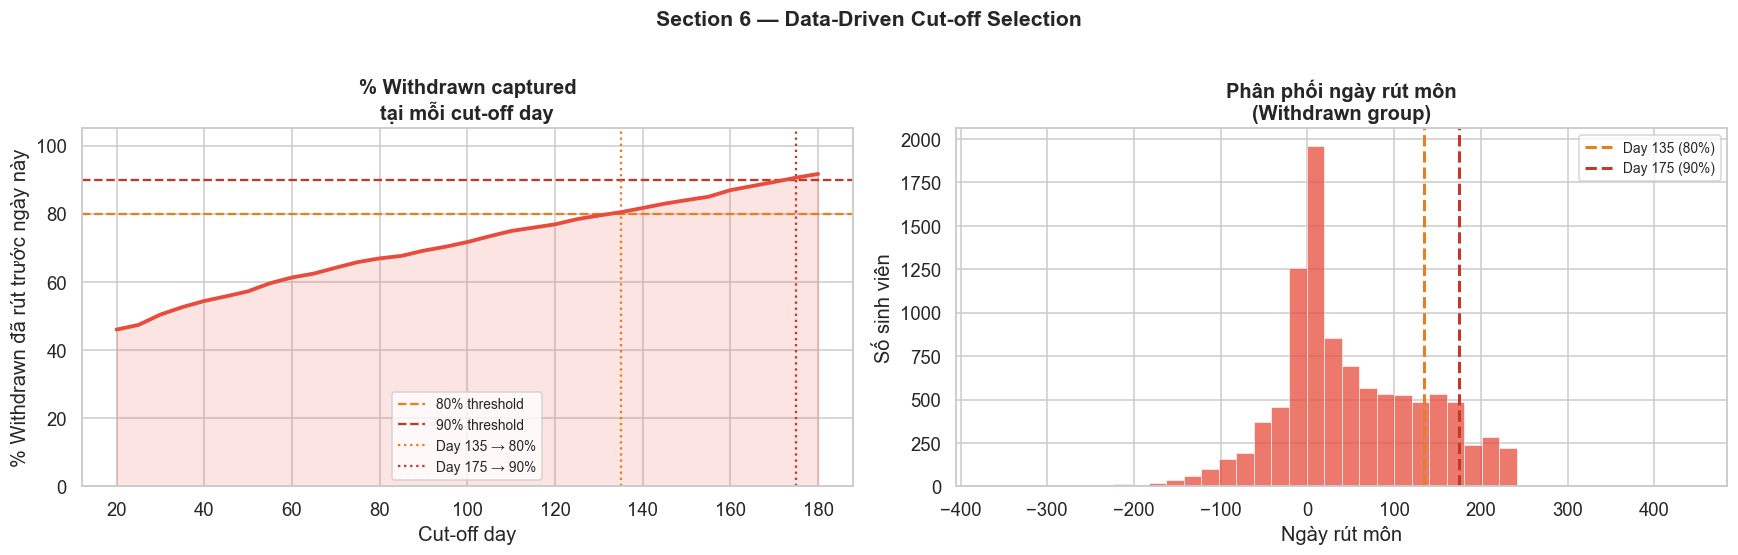


✓ Recommendation: dùng cut-off day 135 (capture 80% Withdrawn).
  Vẫn còn ~126 ngày để can thiệp trước khi kết thúc khóa.


In [7]:
def section6_cutoff_selection():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_crs  = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_reg
        .merge(df_info[['code_module','code_presentation','id_student','final_result']],
               on=['code_module','code_presentation','id_student'], how='inner')
        .merge(df_crs, on=['code_module','code_presentation'], how='left')
    )

    withdrawn = merged[merged['final_result'] == 'Withdrawn'].copy()
    total_w   = len(withdrawn)
    med_len   = df_crs['module_presentation_length'].median()

    cutoffs = range(20, 181, 5)
    records = []
    for c in cutoffs:
        n_captured = (withdrawn['date_unregistration'] <= c).sum()
        records.append({
            'cutoff_day': c,
            'pct_withdrawn': n_captured / total_w * 100,
            'pct_of_module': c / med_len * 100,
        })
    df_co = pd.DataFrame(records)

    # Tìm cutoff nhỏ nhất capture >= 80%
    co_80 = df_co[df_co['pct_withdrawn'] >= 80]['cutoff_day'].min()
    co_90 = df_co[df_co['pct_withdrawn'] >= 90]['cutoff_day'].min()

    print(f'Median module length: {med_len:.0f} ngày')
    print(f'Cut-off capture ≥80% Withdrawn: day {co_80} ({co_80/med_len*100:.1f}% module)')
    print(f'Cut-off capture ≥90% Withdrawn: day {co_90} ({co_90/med_len*100:.1f}% module)')

    # Bảng tóm tắt một số mốc
    show = df_co[df_co['cutoff_day'].isin([30,45,60,75,90,120])].copy()
    show['pct_withdrawn'] = show['pct_withdrawn'].round(1)
    show['pct_of_module'] = show['pct_of_module'].round(1)
    print('\nBảng tóm tắt cut-off:')
    print(show.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Chart 1: % Withdrawn captured vs cutoff
    axes[0].plot(df_co['cutoff_day'], df_co['pct_withdrawn'],
                 color='#e74c3c', linewidth=2.5, zorder=3)
    axes[0].fill_between(df_co['cutoff_day'], df_co['pct_withdrawn'], alpha=0.15, color='#e74c3c')
    axes[0].axhline(80, color='#e67e22', linestyle='--', linewidth=1.5, label='80% threshold')
    axes[0].axhline(90, color='#c0392b', linestyle='--', linewidth=1.5, label='90% threshold')
    axes[0].axvline(co_80, color='#e67e22', linestyle=':', linewidth=1.5,
                    label=f'Day {co_80} → 80%')
    axes[0].axvline(co_90, color='#c0392b', linestyle=':', linewidth=1.5,
                    label=f'Day {co_90} → 90%')
    axes[0].set_title('% Withdrawn captured\ntại mỗi cut-off day', fontweight='bold')
    axes[0].set_xlabel('Cut-off day')
    axes[0].set_ylabel('% Withdrawn đã rút trước ngày này')
    axes[0].legend(fontsize=9)
    axes[0].set_ylim(0, 105)

    # Chart 2: Histogram ngày rút môn của Withdrawn
    axes[1].hist(withdrawn['date_unregistration'].dropna(), bins=40,
                 color='#e74c3c', alpha=0.75, edgecolor='white', linewidth=0.5)
    axes[1].axvline(co_80, color='#e67e22', linestyle='--', linewidth=2,
                    label=f'Day {co_80} (80%)')
    axes[1].axvline(co_90, color='#c0392b', linestyle='--', linewidth=2,
                    label=f'Day {co_90} (90%)')
    axes[1].set_title('Phân phối ngày rút môn\n(Withdrawn group)', fontweight='bold')
    axes[1].set_xlabel('Ngày rút môn')
    axes[1].set_ylabel('Số sinh viên')
    axes[1].legend(fontsize=9)

    plt.suptitle('Section 6 — Data-Driven Cut-off Selection', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f'\n✓ Recommendation: dùng cut-off day {co_80} (capture 80% Withdrawn).')
    print(f'  Vẫn còn ~{med_len - co_80:.0f} ngày để can thiệp trước khi kết thúc khóa.')

section6_cutoff_selection()

---
## Section 7 — Leakage Audit

Chứng minh rằng dùng toàn bộ `studentAssessment` (kể cả Exam cuối kỳ) là data leakage. Xác định assessment nào an toàn với cut-off đã chọn.

Assessment count SAFE vs LEAKAGE at cut-off day 60:
is_safe          LEAKAGE (>day)  SAFE (≤day 60)
assessment_type                                
CMA                          69               7
Exam                          6               0
TMA                          73              33

Submit ratio (submit_day / module_length) per assessment_type:
                   count   mean    std    min    25%    50%    75%    max
assessment_type                                                          
CMA              70527.0  0.546  0.280 -0.033  0.286  0.577  0.804  2.475
Exam              4959.0  0.935  0.025  0.903  0.908  0.927  0.954  1.104
TMA              98426.0  0.366  0.238 -0.047  0.158  0.353  0.565  1.075


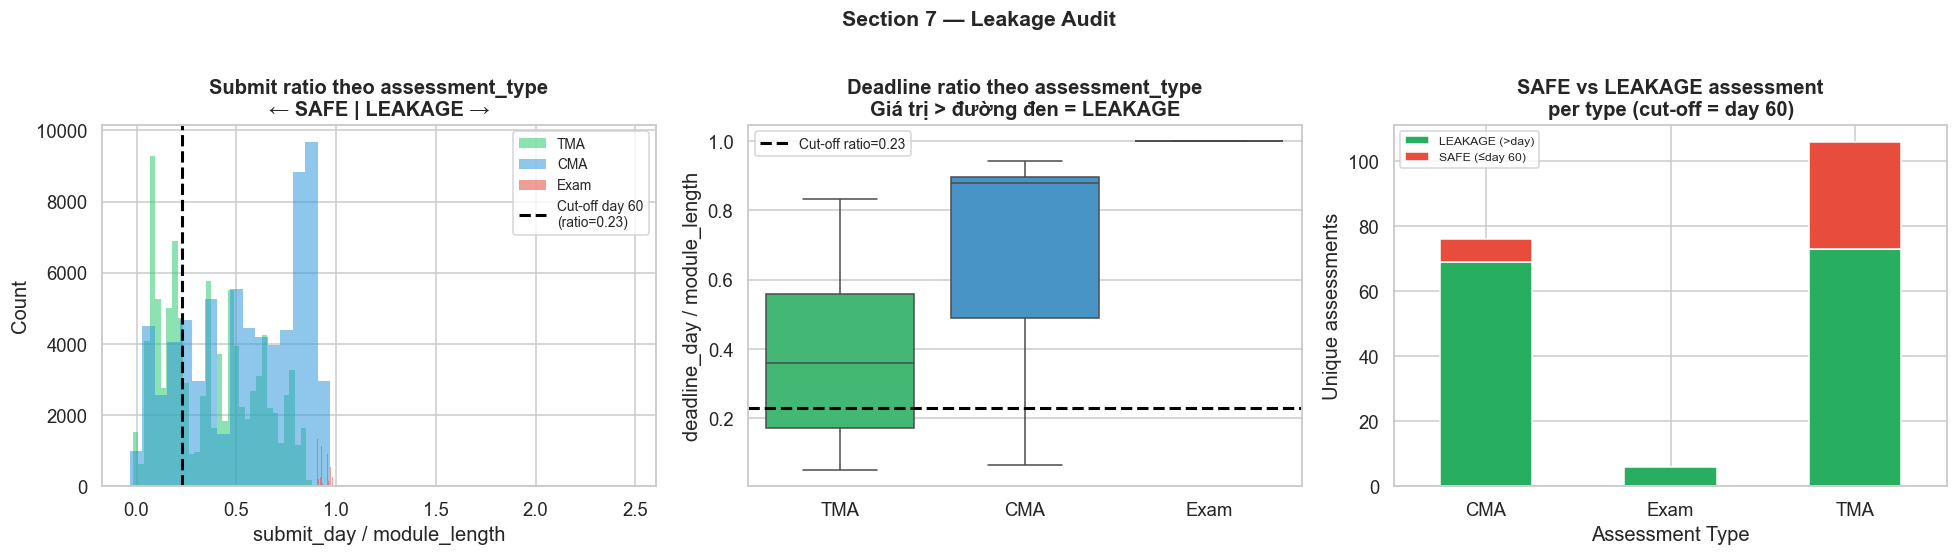


✓ Kết luận: Chỉ dùng assessment có date <= 60.
  Exam gần như luôn ở cuối khóa → KHÔNG dùng Exam score làm feature.


In [8]:
# ← Thay CUTOFF_DAY bằng giá trị output của Section 6
CUTOFF_DAY = 60

def section7_leakage_audit(cutoff_day=CUTOFF_DAY):
    df_sa  = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_crs = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_sa
        .merge(df_ass, on='id_assessment')
        .merge(df_crs, on=['code_module','code_presentation'])
    )
    merged['submit_ratio']   = merged['date_submitted'] / merged['module_presentation_length']
    merged['deadline_ratio'] = merged['date'] / merged['module_presentation_length']
    merged['is_safe']        = merged['date'] <= cutoff_day

    med_len     = df_crs['module_presentation_length'].median()
    cutoff_ratio = cutoff_day / med_len

    # Safe vs leakage count
    safe_tbl = (
        merged.groupby(['assessment_type','is_safe'])['id_assessment']
        .nunique().unstack(fill_value=0)
        .rename(columns={True: f'SAFE (≤day {cutoff_day})', False: 'LEAKAGE (>day)'})
    )
    print(f'Assessment count SAFE vs LEAKAGE at cut-off day {cutoff_day}:')
    print(safe_tbl)

    # Submit ratio stats per type
    print('\nSubmit ratio (submit_day / module_length) per assessment_type:')
    print(merged.groupby('assessment_type')['submit_ratio'].describe().round(3))

    type_colors = {'CMA':'#3498db', 'Exam':'#e74c3c', 'TMA':'#2ecc71'}
    types = merged['assessment_type'].unique()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: submit_ratio histogram per type
    for t in types:
        sub = merged[merged['assessment_type'] == t]['submit_ratio'].dropna()
        axes[0].hist(sub, bins=40, alpha=0.55, label=t,
                     color=type_colors.get(t,'gray'), edgecolor='none')
    axes[0].axvline(cutoff_ratio, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {cutoff_day}\n(ratio={cutoff_ratio:.2f})')
    axes[0].set_title('Submit ratio theo assessment_type\n← SAFE | LEAKAGE →', fontweight='bold')
    axes[0].set_xlabel('submit_day / module_length')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=9)

    # Chart 2: deadline ratio per type (boxplot)
    df_box = merged[['assessment_type','deadline_ratio']].dropna()
    sns.boxplot(data=df_box, x='assessment_type', y='deadline_ratio',
                palette=type_colors, ax=axes[1])
    axes[1].axhline(cutoff_ratio, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off ratio={cutoff_ratio:.2f}')
    axes[1].set_title('Deadline ratio theo assessment_type\nGiá trị > đường đen = LEAKAGE', fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('deadline_day / module_length')
    axes[1].legend(fontsize=9)

    # Chart 3: safe vs leakage stacked bar
    safe_tbl.plot(kind='bar', stacked=True, ax=axes[2],
                  color=['#27ae60','#e74c3c'], edgecolor='white')
    axes[2].set_title(f'SAFE vs LEAKAGE assessment\nper type (cut-off = day {cutoff_day})', fontweight='bold')
    axes[2].set_xlabel('Assessment Type')
    axes[2].set_ylabel('Unique assessments')
    axes[2].tick_params(axis='x', rotation=0)
    axes[2].legend(fontsize=8)

    plt.suptitle('Section 7 — Leakage Audit', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f'\n✓ Kết luận: Chỉ dùng assessment có date <= {cutoff_day}.')
    print('  Exam gần như luôn ở cuối khóa → KHÔNG dùng Exam score làm feature.')

section7_leakage_audit()

---
## Section 8 — VLE Time-series Analysis

Chứng minh rằng `sum_click` tổng là feature kém: một sinh viên click 1000 lần ngày đầu rồi biến mất = sinh viên click 10 lần/ngày đều trong 100 ngày.

Loading studentVle.csv (có thể mất vài giây)...


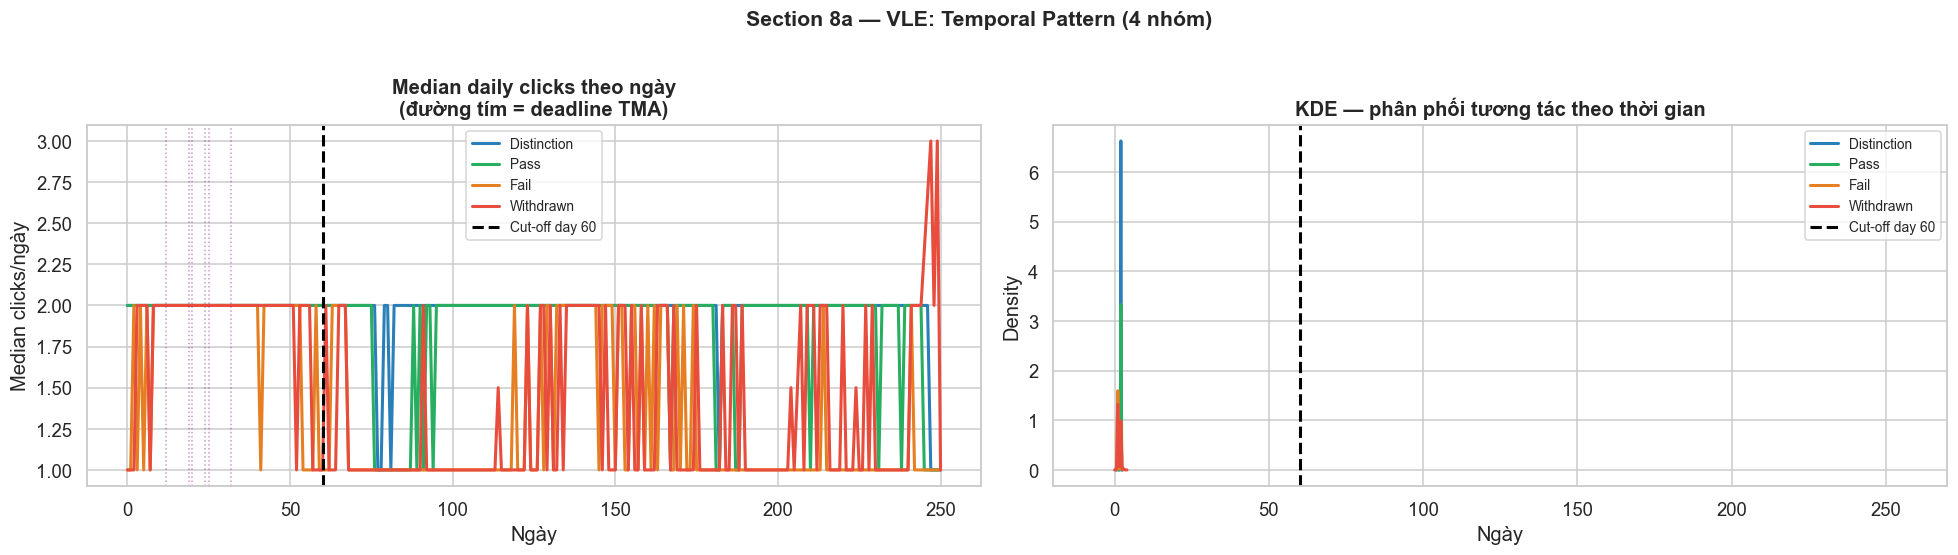

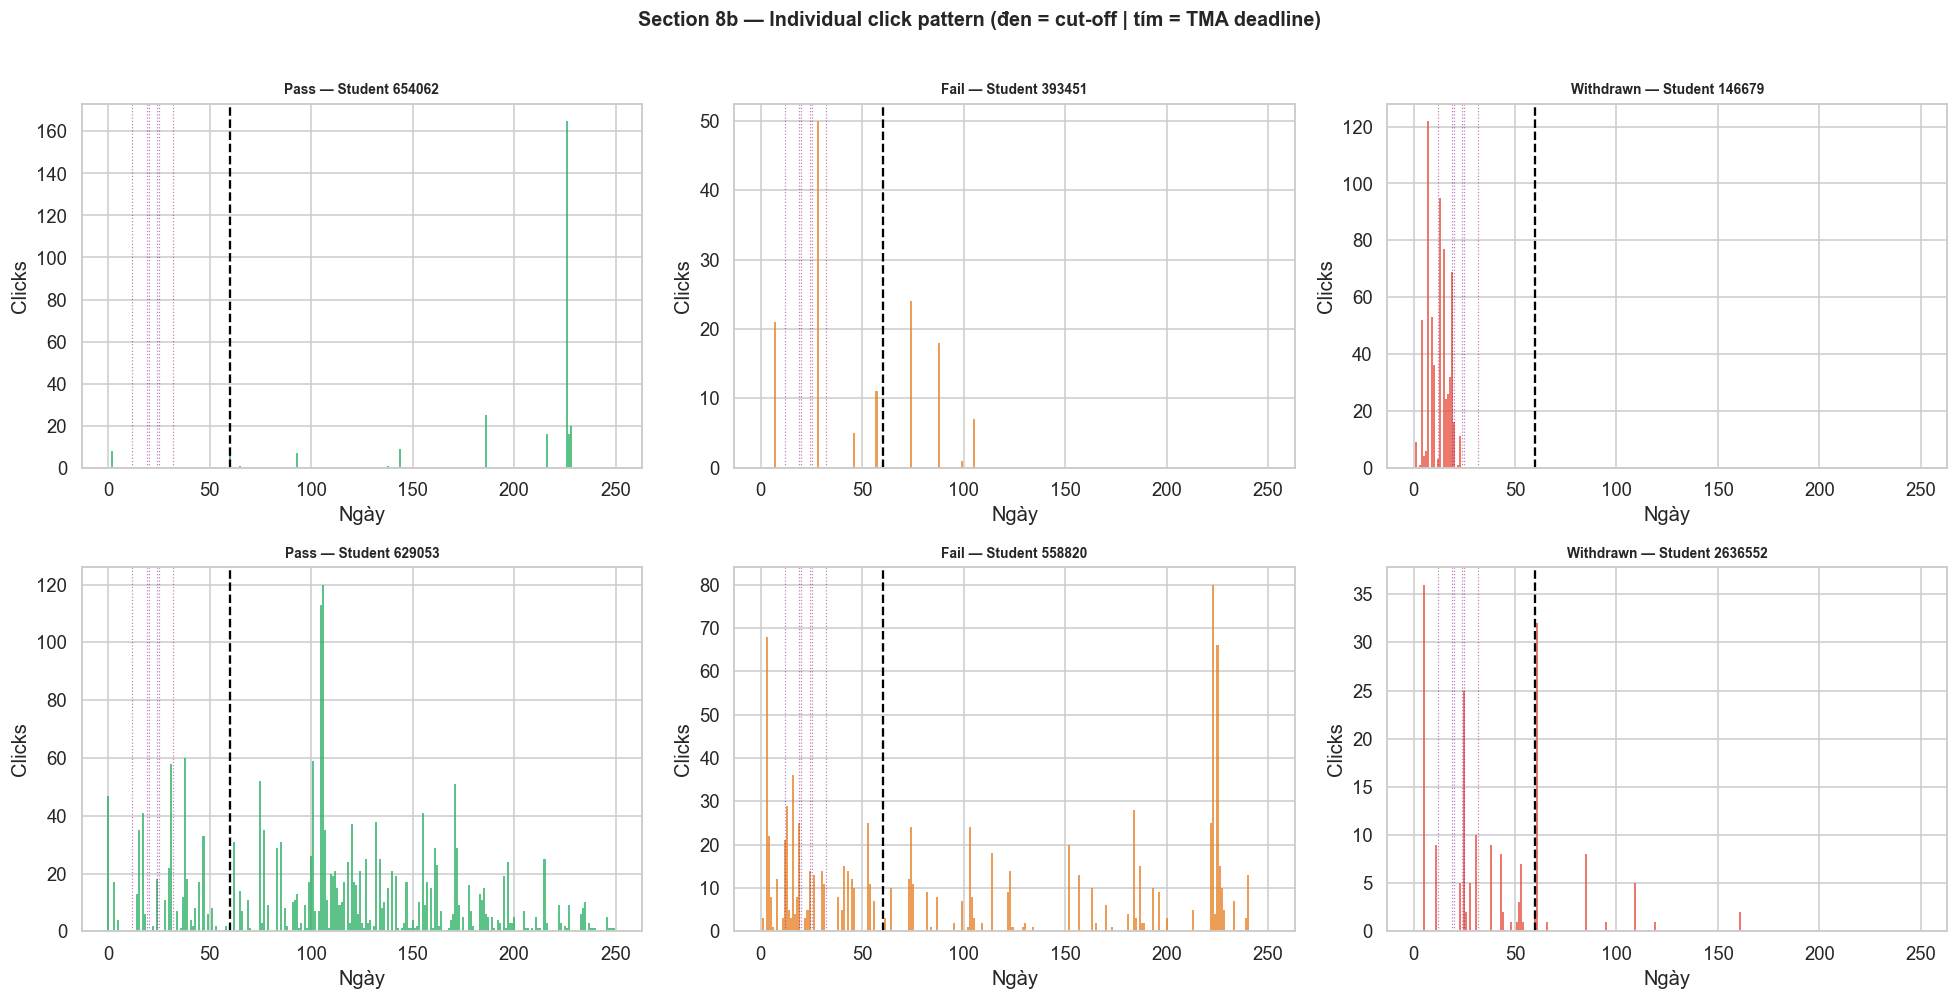

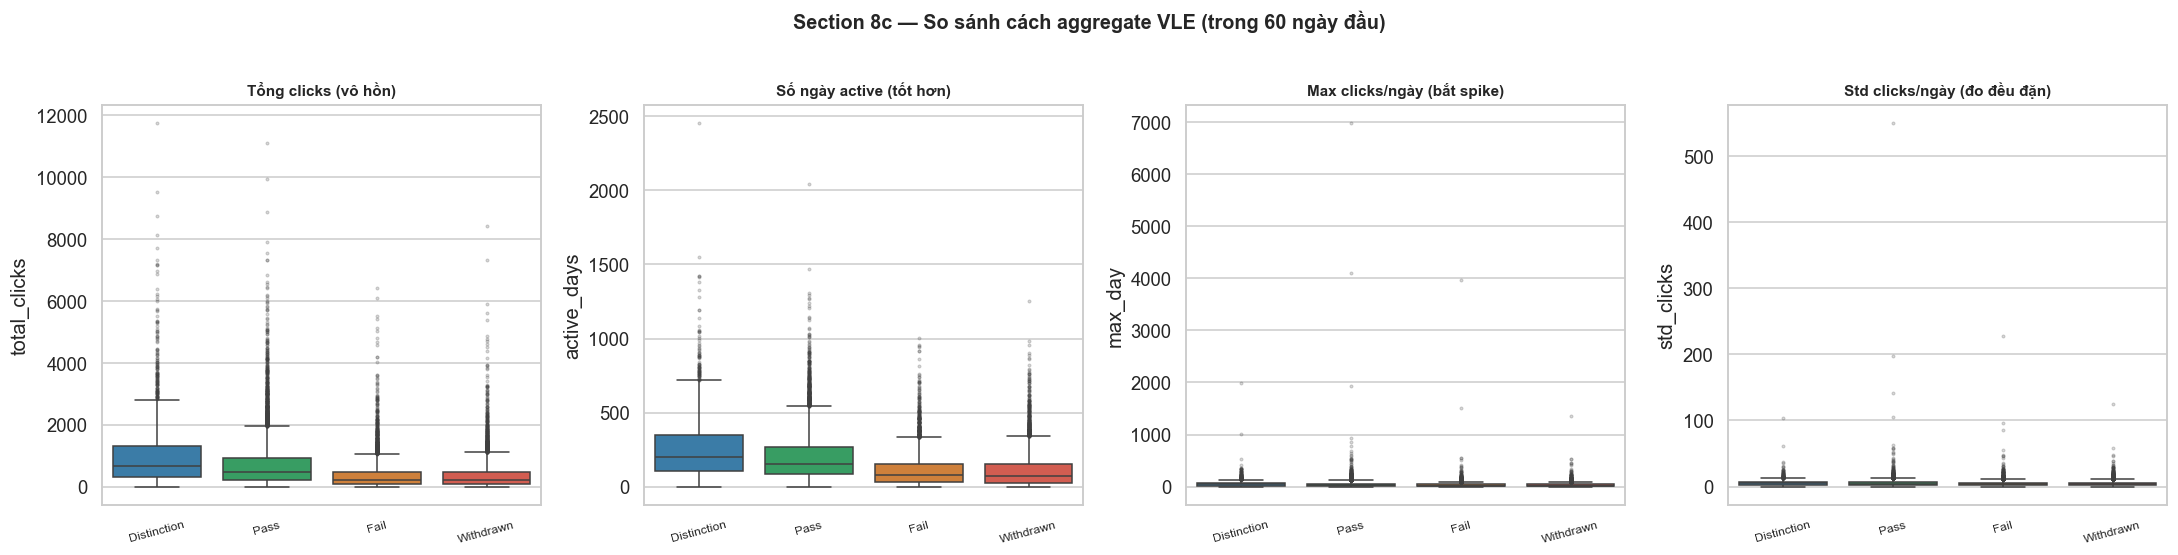


✓ Kết luận: Cần temporal features, KHÔNG chỉ sum_click:
  - active_days       : số ngày có tương tác
  - std_clicks        : độ đều đặn của việc học
  - clicks_week_1..N  : clicks từng tuần
  - last_active_day   : ngày cuối còn online trước cut-off


In [9]:
def section8_vle_timeseries(cutoff_day=CUTOFF_DAY):
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')

    print('Loading studentVle.csv (có thể mất vài giây)...')
    df_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    del df_vle

    result_order  = ['Distinction','Pass','Fail','Withdrawn']
    result_colors = {'Distinction':'#2980b9','Pass':'#27ae60','Fail':'#e67e22','Withdrawn':'#e74c3c'}
    tma_dates = df_ass[df_ass['assessment_type'] == 'TMA']['date'].sort_values().unique()[:6]

    # ── Chart 1: Median daily clicks — 4 nhóm ────────────────────────────
    daily = (
        vle[vle['date'].between(0, 250)]
        .groupby(['final_result','date'])['sum_click']
        .median().reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    for res in result_order:
        g = daily[daily['final_result'] == res]
        axes[0].plot(g['date'], g['sum_click'],
                     label=res, color=result_colors[res], linewidth=2)
    axes[0].axvline(cutoff_day, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {cutoff_day}')
    for d in tma_dates:
        if d <= 250:
            axes[0].axvline(d, color='purple', linestyle=':', alpha=0.4, linewidth=1)
    axes[0].set_title('Median daily clicks theo ngày\n(đường tím = deadline TMA)', fontweight='bold')
    axes[0].set_xlabel('Ngày')
    axes[0].set_ylabel('Median clicks/ngày')
    axes[0].legend(fontsize=9)

    # ── Chart 2: KDE click density ────────────────────────────────────────
    vle_cut = vle[vle['date'].between(0, 250)].copy()
    for res in result_order:
        g = vle_cut[vle_cut['final_result'] == res]
        g.groupby('date')['sum_click'].median().plot.kde(
            ax=axes[1], label=res, color=result_colors[res], linewidth=2
        )
    axes[1].axvline(cutoff_day, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {cutoff_day}')
    axes[1].set_title('KDE — phân phối tương tác theo thời gian', fontweight='bold')
    axes[1].set_xlabel('Ngày')
    axes[1].set_ylabel('Density')
    axes[1].legend(fontsize=9)
    axes[1].set_xlim(-20, 270)

    plt.suptitle('Section 8a — VLE: Temporal Pattern (4 nhóm)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Chart 3: Individual click pattern — 2x3 grid ─────────────────────
    show_groups = [('Pass','#27ae60'), ('Fail','#e67e22'), ('Withdrawn','#e74c3c')]
    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))

    for col_idx, (res, color) in enumerate(show_groups):
        pool = df_info[df_info['final_result'] == res]['id_student']
        sample_ids = pool.sample(min(2, len(pool)), random_state=RANDOM_STATE)
        for row_idx, sid in enumerate(sample_ids):
            ax = axes2[row_idx][col_idx]
            s = (
                vle[vle['id_student'] == sid]
                .groupby('date')['sum_click'].sum()
                .reindex(range(0, 251), fill_value=0)
            )
            ax.bar(s.index, s.values, width=1, color=color, alpha=0.75, edgecolor='none')
            for d in tma_dates:
                if d <= 250:
                    ax.axvline(d, color='purple', linestyle=':', alpha=0.5, linewidth=0.8)
            ax.axvline(cutoff_day, color='black', linestyle='--', linewidth=1.5)
            ax.set_title(f'{res} — Student {sid}', fontsize=9, fontweight='bold')
            ax.set_xlabel('Ngày')
            ax.set_ylabel('Clicks')

    plt.suptitle('Section 8b — Individual click pattern (đen = cut-off | tím = TMA deadline)',
                  fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Chart 4: sum_click vs better aggregates ───────────────────────────
    vle_pre = vle[vle['date'] <= cutoff_day].copy()
    agg = (
        vle_pre.groupby(['id_student','final_result'])['sum_click']
        .agg(
            total_clicks='sum',
            active_days='count',
            max_day='max',
            std_clicks='std'
        )
        .reset_index()
    )
    agg['final_result'] = pd.Categorical(agg['final_result'], categories=result_order)

    metrics = [
        ('total_clicks', 'Tổng clicks (vô hồn)'),
        ('active_days',  'Số ngày active (tốt hơn)'),
        ('max_day',      'Max clicks/ngày (bắt spike)'),
        ('std_clicks',   'Std clicks/ngày (đo đều đặn)'),
    ]
    fig3, axes3 = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (col, title) in zip(axes3, metrics):
        sns.boxplot(data=agg, x='final_result', y=col, order=result_order,
                    palette=result_colors, ax=ax,
                    flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
        ax.set_title(title, fontweight='bold', fontsize=10)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=15, labelsize=8)

    plt.suptitle(f'Section 8c — So sánh cách aggregate VLE (trong {cutoff_day} ngày đầu)',
                  fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print('\n✓ Kết luận: Cần temporal features, KHÔNG chỉ sum_click:')
    print('  - active_days       : số ngày có tương tác')
    print('  - std_clicks        : độ đều đặn của việc học')
    print('  - clicks_week_1..N  : clicks từng tuần')
    print('  - last_active_day   : ngày cuối còn online trước cut-off')

section8_vle_timeseries()

---
## Summary — Các quyết định được justify bởi EDA

| # | Quyết định | Justify bởi |
|---|---|---|
| 1 | NaN `date_unregistration` = "không rút môn" → KHÔNG dropna() | Section 2 |
| 2 | NaN `score` = "không nộp bài" → fillna(0) | Section 2 |
| 3 | Không gộp raw score cross-module | Section 4 |
| 4 | Thêm feature `semester` (B vs J) | Section 5 |
| 5 | Cut-off day = X (chọn từ Section 6) | Section 6 |
| 6 | Chỉ dùng assessment có date ≤ cut-off | Section 7 |
| 7 | Không dùng Exam score | Section 7 |
| 8 | Dùng temporal VLE features thay vì chỉ sum_click | Section 8 |